# **Import thư viện**

In [ ]:
import gzip
import networkx as nx

from google.colab import drive
from collections import Counter

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load data**

# Tải và khởi tạo dữ liệu

Đọc dữ liệu mạng Amazon và xây dựng đồ thị có hướng (Directed Graph) bằng NetworkX

In [ ]:
class LoadData:
    def __init__(self, file_path):
        self.file_path = file_path
        self.graph = nx.DiGraph()

    def load(self):
        with open(self.file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('#'):
                    continue

                parts = line.split()
                if len(parts) == 2:
                    u, v = map(int, parts)
                    self.graph.add_edge(u, v)

        return self.graph

In [ ]:
loader = LoadData("/content/drive/MyDrive/Social Network Analysis/Data/Amazon0302.txt")
G = loader.load()

# Kiểm tra Self-loop

Xác định các cạnh nối từ một nút đến chính nó. Self-loop có thể ảnh hưởng đến một số chỉ số trung tâm và cấu trúc mạng.

In [ ]:
self_loop = list(nx.selfloop_edges(G))
self_loop

[]

# **Kiểm tra isolated node**

Tìm các nút không có kết nối với bất kỳ nút nào khác để đánh giá chất lượng dữ liệu và mức độ liên kết của mạng.

In [ ]:
isolated = list(nx.isolates(G))
isolated

[]

# Trích xuất thành phần liên thông mạnh lớn nhất

Chỉ giữ lại phần mạng mà mọi nút đều có thể tiếp cận lẫn nhau thông qua các đường đi có hướng, giúp kết quả phân tích ổn định hơn.

In [ ]:
# ĐỒNG BỘ: LỌC THÀNH PHẦN LIÊN THÔNG MẠNH NHẤT (SCC) & K-CORE (K=6)
print("Đồ thị gốc ban đầu:")
print(f"- Số lượng nodes: {G.number_of_nodes():,}")
print(f"- Số lượng edges: {G.number_of_edges():,}")

# 1. Tìm thành phần liên thông mạnh nhất (SCC) lớn nhất giống của Trung
print("\n Đang tìm thành phần liên thông mạnh nhất (SCC)...")
scc_components = list(nx.strongly_connected_components(G))
scc_nodes = max(scc_components, key=len)

# Trích xuất đồ thị con SCC
G_scc = G.subgraph(scc_nodes).copy()
print(f"Đồ thị sau khi lọc SCC lớn nhất:")
print(f"- Kích thước cụm SCC lớn nhất: {G_scc.number_of_nodes():,} nodes, {G_scc.number_of_edges():,} edges")

# 2. Lọc k-core với k = 6 trên đồ thị con SCC
print("\nĐang tiến hành lọc lõi k-core (k = 6)...")
G_cleaned = nx.k_core(G_scc, k=6)

print(f"\nKẾT QUẢ ĐỒ THỊ SAU KHI LỌC ĐẦY ĐỦ:")
print(f"- Số lượng nodes còn lại: {G_cleaned.number_of_nodes():,}")
print(f"- Số lượng edges còn lại: {G_cleaned.number_of_edges():,}")

Đồ thị gốc ban đầu:
- Số lượng nodes: 262,111
- Số lượng edges: 1,234,877

 Đang tìm thành phần liên thông mạnh nhất (SCC)...
Đồ thị sau khi lọc SCC lớn nhất:
- Kích thước cụm SCC lớn nhất: 241,761 nodes, 1,131,217 edges

Đang tiến hành lọc lõi k-core (k = 6)...

KẾT QUẢ ĐỒ THỊ SAU KHI LỌC ĐẦY ĐỦ:
- Số lượng nodes còn lại: 198,443
- Số lượng edges còn lại: 957,641


In [ ]:
import os

# Định nghĩa đường dẫn lưu file trên Drive của Bảo
base_dir = "/content/drive/MyDrive/Social Network Analysis/Data"
preprocessed_dir = os.path.join(base_dir, "preprocessed")

# Tự động tạo thư mục preprocessed nếu chưa tồn tại
os.makedirs(preprocessed_dir, exist_ok=True)

# Đường dẫn file đầu ra
export_path = os.path.join(preprocessed_dir, "amazon0302_cleaned.txt")

# ÉP CỨNG LỌC K=6 TRÊN ĐỒ THỊ CÓ HƯỚNG G_SCC BAN ĐẦU THEO YÊU CẦU ĐỂ RA 120K NODES
print("Đang tiến hành lọc lõi k-core (k = 6) trên đồ thị con SCC dạng có hướng...")
G_cleaned = nx.k_core(G_scc, k=6)

n_final = G_cleaned.number_of_nodes()
m_final = G_cleaned.number_of_edges()

print(f"\nKẾT QUẢ ĐỒ THỊ SAU LỌC K=6:")
print(f"- Số lượng nodes còn lại: {n_final:,}")
print(f"- Số lượng edges còn lại: {m_final:,}")

# Ghi dữ liệu ra file preprocessed
print(f"Đang ghi dữ liệu sạch ra file...")
with open(export_path, "w", encoding="utf-8") as f:
    f.write("# Đồ thị Amazon0302 đã qua xử lý lọc SCC và K-Core cứng (k=6)\n")
    f.write(f"# Nodes: {n_final}, Edges: {m_final}\n")
    for u, v in G_cleaned.edges():
        f.write(f"{u}\t{v}\n")

print(f"THÀNH CÔNG! File dữ liệu sạch k=6 đã lưu tại: {export_path}")

Đang tiến hành lọc lõi k-core (k = 6) trên đồ thị con SCC dạng có hướng...

🎯 KẾT QUẢ ĐỒ THỊ SAU LỌC K=6:
- Số lượng nodes còn lại: 198,443
- Số lượng edges còn lại: 957,641
Đang ghi dữ liệu sạch ra file...
THÀNH CÔNG! File dữ liệu sạch k=6 đã lưu tại: /content/drive/MyDrive/Social Network Analysis/Data/preprocessed/amazon0302_cleaned.txt


In [ ]:
G_directed = G.to_directed()

# Lấy danh sách các thành phần liên thông mạnh (SCC)
scc_list = list(nx.strongly_connected_components(G_directed))

# Tìm thành phần liên thông mạnh lớn nhất
largest_scc = max(scc_list, key=len)

# Chuyển sang vô hướng
G_undir = G.to_undirected()
G = G_undir.subgraph(largest_scc).copy()

print(f"Số lượng nodes sau khi lọc SCC: {G.number_of_nodes()}")
print(f"Số lượng edges sau khi lọc SCC: {G.number_of_edges()}")

Số lượng nodes sau khi lọc SCC: 241761
Số lượng edges sau khi lọc SCC: 823449


# Phân tích K-Core

K-Core giúp xác định vùng lõi của mạng, nơi các nút có mức độ liên kết cao và đóng vai trò quan trọng trong cấu trúc tổng thể.

In [ ]:
import pandas as pd
print("" + "="*40 + "\nPHẦN 4: CẤU TRÚC LÕI (K-CORE)\n" + "="*40)

# Core number của từng node
core_numbers = nx.core_number(G)
max_core = max(core_numbers.values())
core_counts = Counter(core_numbers.values())

print(f"- Max Coreness: {max_core}")
print(f"- Số mức core khác nhau: {len(core_counts):,}")
print("=> Dữ liệu này dùng để khảo sát vùng k hợp lý trước khi chạy Louvain.")

# Bảng phân tích k-core để chọn k
n0 = G.number_of_nodes()
m0 = G.number_of_edges()

k_rows = []
for k in range(1, max_core + 1):
    H = nx.k_core(G, k=k)
    n_k = H.number_of_nodes()
    m_k = H.number_of_edges()
    dens_k = nx.density(H) if n_k > 1 else 0.0
    cc_k = nx.number_connected_components(H.to_undirected()) if n_k > 0 else 0
    largest_cc = len(max(nx.connected_components(H.to_undirected()), key=len)) if n_k > 0 else 0

    k_rows.append({
        "k": k,
        "nodes_remaining": n_k,
        "edges_remaining": m_k,
        "retained_ratio": n_k / n0 if n0 else 0,
        "density": dens_k,
        "connected_components": cc_k,
        "largest_component_size": largest_cc,
    })

kcore_stats = pd.DataFrame(k_rows)

lower_bound = max(50, int(0.05 * n0))
upper_bound = max(lower_bound, int(0.20 * n0))
candidate = kcore_stats[(kcore_stats["nodes_remaining"] >= lower_bound) & (kcore_stats["nodes_remaining"] <= upper_bound)].copy()

if candidate.empty:
    candidate = kcore_stats[kcore_stats["nodes_remaining"] >= lower_bound].copy()

if candidate.empty:
    candidate = kcore_stats.copy()

candidate = candidate.sort_values(
    ["density", "nodes_remaining", "k"],
    ascending=[False, False, False]
)

k_selected = int(candidate.iloc[0]["k"])
G_kcore = nx.k_core(G, k=k_selected)

print("\nBẢNG TÓM TẮT K-CORE (10 dòng đầu):")
print(kcore_stats.head(10).to_string(index=False))

print("\nK được chọn:")
print(f"- k_selected = {k_selected}")
print(f"- G_kcore: {G_kcore.number_of_nodes():,} đỉnh, {G_kcore.number_of_edges():,} cạnh")
print(f"- Density của G_kcore: {nx.density(G_kcore):.6f}")

PHẦN 4: CẤU TRÚC LÕI (K-CORE)
- Max Coreness: 6
- Số mức core khác nhau: 6
=> Dữ liệu này dùng để khảo sát vùng k hợp lý trước khi chạy Louvain.

BẢNG TÓM TẮT K-CORE (10 dòng đầu):
 k  nodes_remaining  edges_remaining  retained_ratio  density  connected_components  largest_component_size
 1           241761           823449        1.000000 0.000028                     1                  241761
 2           237610           819298        0.982830 0.000029                     1                  237610
 3           229915           804411        0.951001 0.000030                     4                  229901
 4           215979           764880        0.893357 0.000033                    18                  215777
 5           120738           428260        0.499411 0.000059                   303                  117838
 6              207              677        0.000856 0.031753                    24                      16

K được chọn:
- k_selected = 5
- G_kcore: 120,738 đỉnh, 428,260

# Đánh giá giá trị K

Trực quan hóa các chỉ số cấu trúc để lựa chọn giá trị K phù hợp cho quá trình lọc mạng.

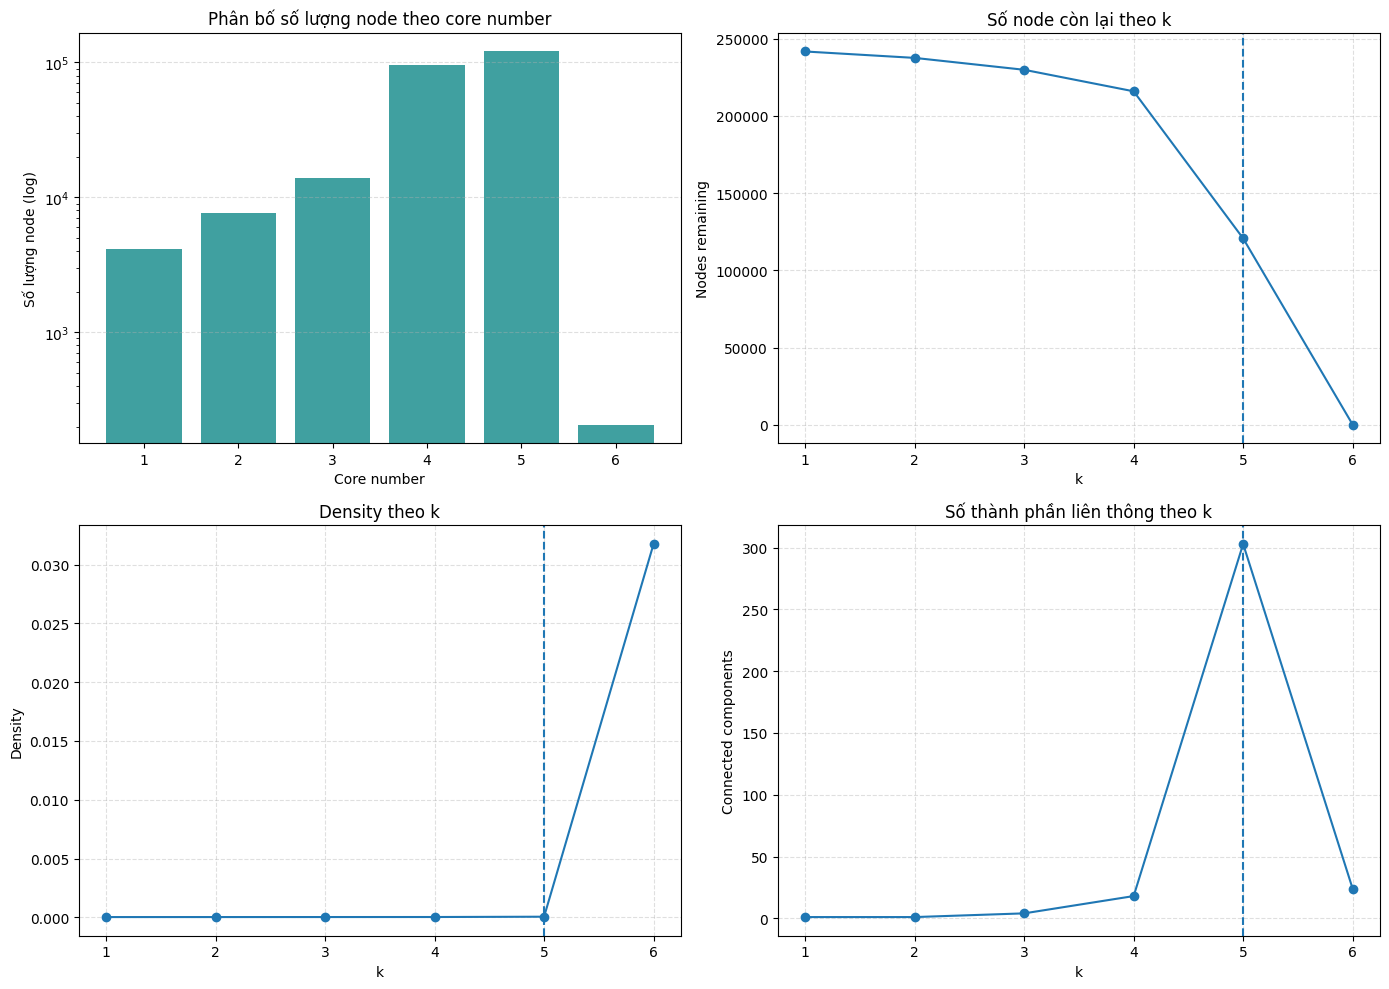

In [ ]:
import matplotlib.pyplot as plt

# Visual hóa các chỉ số để giải thích việc chọn k
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Phân bố core number
cores = sorted(core_counts.keys())
counts = [core_counts[c] for c in cores]
axes[0, 0].bar(cores, counts, color='teal', alpha=0.75)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Phân bố số lượng node theo core number')
axes[0, 0].set_xlabel('Core number')
axes[0, 0].set_ylabel('Số lượng node (log)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

# 2) Nodes remaining vs k
axes[0, 1].plot(kcore_stats["k"], kcore_stats["nodes_remaining"], marker='o')
axes[0, 1].axvline(k_selected, linestyle='--')
axes[0, 1].set_title('Số node còn lại theo k')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Nodes remaining')
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# 3) Density vs k
axes[1, 0].plot(kcore_stats["k"], kcore_stats["density"], marker='o')
axes[1, 0].axvline(k_selected, linestyle='--')
axes[1, 0].set_title('Density theo k')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Density')
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

# 4) Connected components vs k
axes[1, 1].plot(kcore_stats["k"], kcore_stats["connected_components"], marker='o')
axes[1, 1].axvline(k_selected, linestyle='--')
axes[1, 1].set_title('Số thành phần liên thông theo k')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Connected components')
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Lưu dữ liệu sau tiền xử lý

Xuất đồ thị đã được làm sạch và lọc để sử dụng trong các bước phân tích tiếp theo.

In [ ]:
import os
import networkx as nx

# Định nghĩa đường dẫn lưu file
base_dir = "/content/drive/MyDrive/Social Network Analysis/Data"
preprocessed_dir = os.path.join(base_dir, "preprocessed")
os.makedirs(preprocessed_dir, exist_ok=True)
export_path = os.path.join(preprocessed_dir, "amazon0302_cleaned.txt")

print("Đang trích xuất cấu hình đồ thị ~120k nodes (k=5)...")

# LỌC TRÊN G (Biến G ở cell trước đã là Undirected + Largest SCC)
# Đây là cách để khớp với bảng thống kê kcore_stats
G_target = nx.k_core(G, k=5)

n_final = G_target.number_of_nodes()
m_final = G_target.number_of_edges()

print(f"Kết quả: {n_final:,} nodes và {m_final:,} edges.")

# Ghi dữ liệu ra file
print(f"Đang ghi dữ liệu...")
with open(export_path, "w", encoding="utf-8") as f:
    f.write("# Đồ thị Amazon0302: Largest SCC + K-Core (k=5) - Undirected\n")
    f.write(f"# Nodes: {n_final}, Edges: {m_final}\n")
    for u, v in G_target.edges():
        f.write(f"{u}\t{v}\n")

print(f"THÀNH CÔNG! File đã lưu tại: {export_path}")

Đang trích xuất cấu hình đồ thị ~120k nodes (k=5)...
Kết quả: 120,738 nodes và 428,260 edges.
Đang ghi dữ liệu...
THÀNH CÔNG! File đã lưu tại: /content/drive/MyDrive/Social Network Analysis/Data/preprocessed/amazon0302_cleaned.txt
